# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the UCI description and the Materials and Methods section of the accompanying paper (Moro et al., 2014), the data represent **17 marketing campaigns** conducted by a Portuguese banking institution. The campaigns span from **May 2008 to November 2010**, with the full dataset (bank-additional-full.csv) containing 41,188 phone contacts ordered by date.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [22]:
import pandas as pd

In [23]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [24]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [25]:
# Check for missing values (stored as 'unknown' in categoricals per the description)
print("Missing values (NaN):")
print(df.isnull().sum())
print("\n'unknown' counts in categorical columns:")
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']
for c in cat_cols:
    if c in df.columns:
        print(f"  {c}: {(df[c] == 'unknown').sum()}")
print("\nData types:")
print(df.dtypes)
# Conclusion: No NaN; categorical 'unknown' can be kept as a category. 
# Numeric columns are read correctly; we may one-hot encode categoricals for modeling.

Missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

'unknown' counts in categorical columns:
  job: 330
  marital: 80
  education: 1731
  default: 8597
  housing: 990
  loan: 990
  poutcome: 0

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Business Objective:** Predict whether a client will subscribe to a **term deposit** (variable `y`: yes/no) based on bank client and campaign-related features. The goal is to support the marketing team by identifying which clients are most likely to subscribe, so that outreach (e.g., phone campaigns) can be prioritized and resources used more efficiently.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [27]:
# Bank client features only (per problem description)
bank_client_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X_raw = df[bank_client_cols].copy()
y = (df['y'] == 'yes').astype(int)  # binary: 1 = subscribed, 0 = not

In [28]:
# One-hot encode categorical features
X_encoded = pd.get_dummies(X_raw, columns=['job', 'marital', 'education', 'default', 'housing', 'loan'], drop_first=False)
X_encoded.head()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes
0,56,False,False,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,57,False,False,False,False,False,False,False,True,False,...,False,False,True,False,True,False,False,True,False,False
2,37,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False
3,40,True,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4,56,False,False,False,False,False,False,False,True,False,...,False,True,False,False,True,False,False,False,False,True


In [29]:
X = X_encoded.values  # use encoded features; scaling will be done in pipelines to avoid data leakage
feature_names = X_encoded.columns.tolist()
print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (41188, 34)
Target distribution:
 y
0    36548
1     4640
Name: count, dtype: int64


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 30891 Test size: 10297


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [31]:
# Baseline: predict the majority class (no subscription)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print("Baseline (majority class) accuracy:", round(baseline_accuracy, 4))
print("Our classifiers should beat this to be useful.")

Baseline (majority class) accuracy: 0.8873
Our classifiers should beat this to be useful.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)  # simple model on bank-client features only

LogisticRegression(max_iter=1000, random_state=42)

### Problem 9: Score the Model

What is the accuracy of your model?

In [33]:
print("Logistic Regression - Train accuracy:", round(lr.score(X_train, y_train), 4))
print("Logistic Regression - Test accuracy:", round(lr.score(X_test, y_test), 4))

Logistic Regression - Train accuracy: 0.8873
Logistic Regression - Test accuracy: 0.8873


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [34]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def fit_and_score(name, model, X_tr, y_tr, X_te, y_te):
    start = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    return {'Model': name, 'Train Time': train_time, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc}

# Models that benefit from scaling (use pipeline)
knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
svm = Pipeline([('scaler', StandardScaler()), ('clf', SVC())])
# LR and DT as before (LR often scaled too for fairness; DT doesn't need it)
lr_pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
dt = DecisionTreeClassifier(random_state=42)

results = [
    fit_and_score('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test),
    fit_and_score('KNN', knn, X_train, y_train, X_test, y_test),
    fit_and_score('Decision Tree', dt, X_train, y_train, X_test, y_test),
    fit_and_score('SVM', svm, X_train, y_train, X_test, y_test),
]
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.059881,0.887346,0.887346
1,KNN,0.050608,0.891230,0.879965
2,Decision Tree,0.092050,0.917775,0.866660
3,SVM,12.551893,0.887670,0.887152


In [35]:
# Format for display
comparison_df.round(4)

# Save results to file
import os
os.makedirs('results', exist_ok=True)
comparison_df.round(4).to_csv('results/model_comparison.csv', index=False)
print("Saved to results/model_comparison.csv")

Saved to results/model_comparison.csv


/var/folders/q1/2blhxrl50v33m0s2lt6tczbh0000gq/T/ipykernel_60804/2845758815.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')


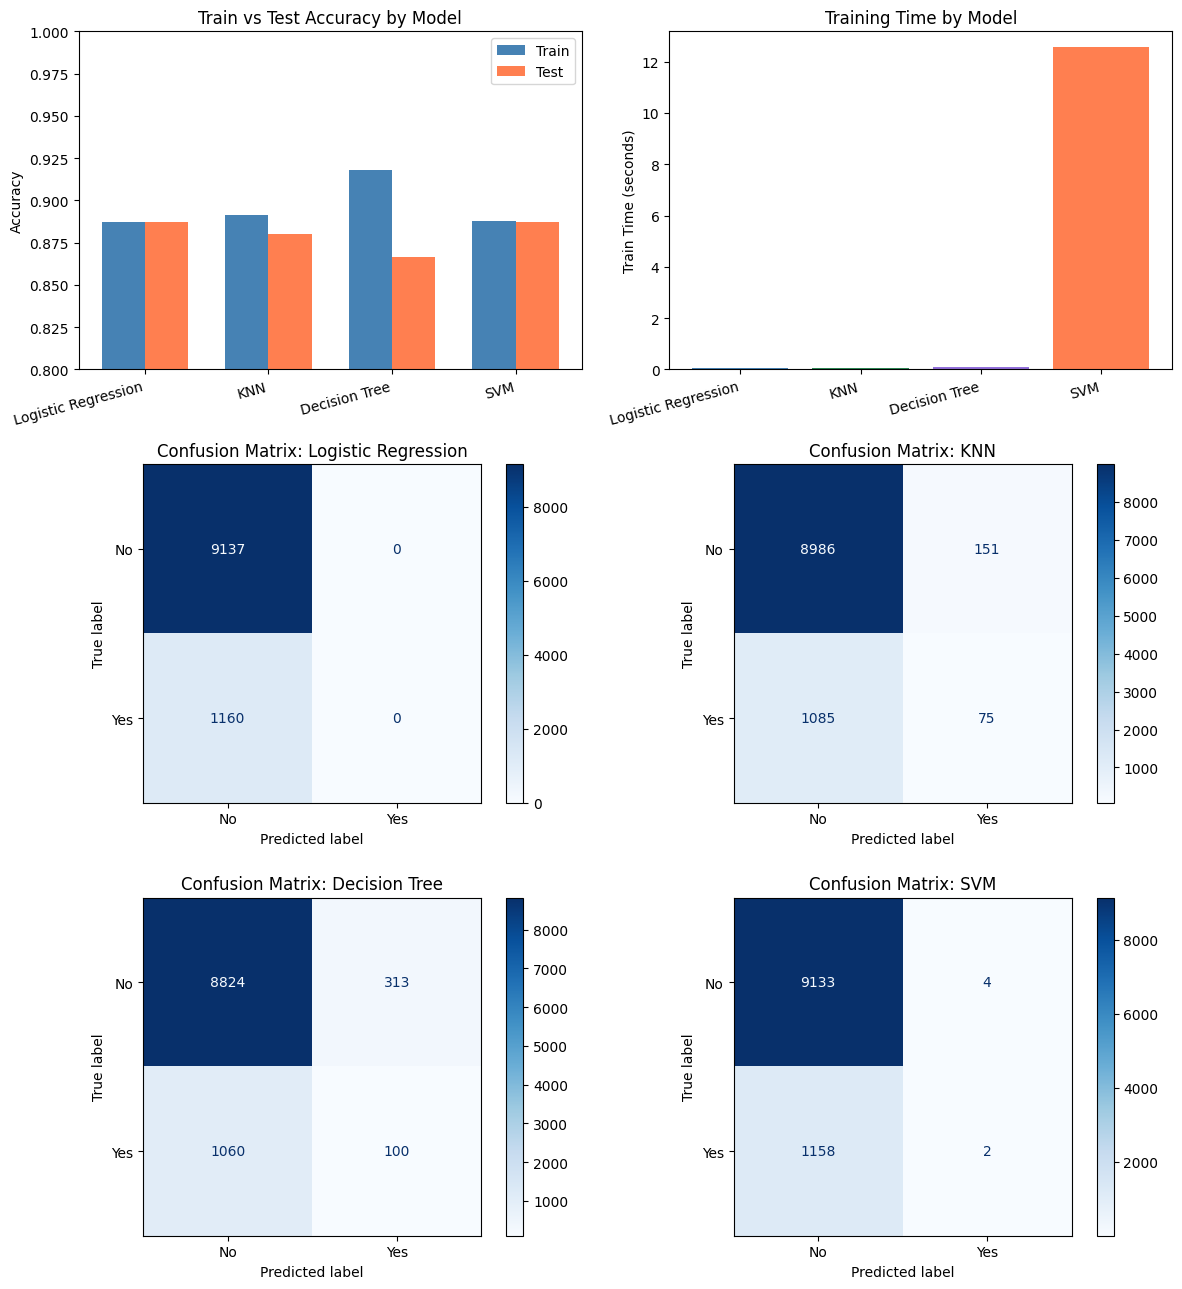

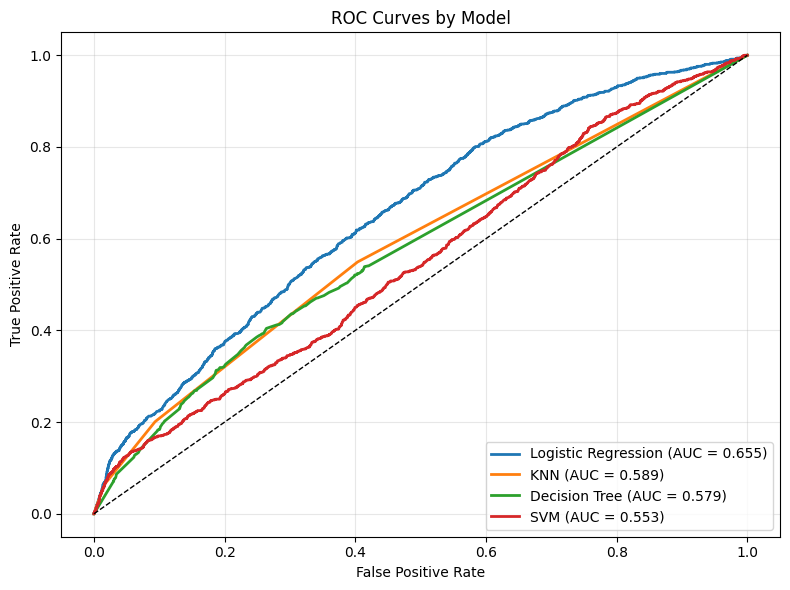

In [36]:
# Visualizations for each model (Problem 10)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Figure 1: Accuracy, Train Time, and Confusion Matrices (3 rows x 2 cols)
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# 1. Bar chart: Train vs Test accuracy by model
ax = axes[0, 0]
x = range(len(comparison_df))
w = 0.35
ax.bar([i - w/2 for i in x], comparison_df['Train Accuracy'], w, label='Train', color='steelblue')
ax.bar([i + w/2 for i in x], comparison_df['Test Accuracy'], w, label='Test', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy by Model')
ax.legend()
ax.set_ylim(0.8, 1.0)

# 2. Bar chart: Train time by model
ax = axes[0, 1]
colors = ['steelblue', 'seagreen', 'mediumpurple', 'coral']
ax.bar(comparison_df['Model'], comparison_df['Train Time'], color=colors)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Train Time (seconds)')
ax.set_title('Training Time by Model')

# 3. Confusion matrices (one per model)
models_list = [lr_pipe, knn, dt, svm]
for idx, (name, model) in enumerate(zip(comparison_df['Model'], models_list)):
    row, col = 1 + idx // 2, idx % 2
    ax = axes[row, col]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.savefig('results/model_comparison_plots.png', dpi=100, bbox_inches='tight')
plt.show()

# Figure 2: ROC curves for each model
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for name, model in zip(comparison_df['Model'], models_list):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves by Model')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/model_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

#### Cross-Validation and Visualization

We use 5-fold cross-validation to estimate model performance more reliably and visualize the distribution of fold scores per model.

In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold CV on training set (same models as in Problem 10)
cv_results = []
for name, model in zip(comparison_df['Model'], models_list):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std(),
        'Fold 1': scores[0], 'Fold 2': scores[1], 'Fold 3': scores[2], 'Fold 4': scores[3], 'Fold 5': scores[4]
    })
cv_df = pd.DataFrame(cv_results)
cv_df[['Model', 'CV Mean', 'CV Std']].round(4)

In [ ]:
# Save CV summary to file
cv_df[['Model', 'CV Mean', 'CV Std']].to_csv('results/cross_validation_scores.csv', index=False)
print("Saved to results/cross_validation_scores.csv")

In [ ]:
# Cross-validation visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Box plot: distribution of CV fold scores per model
fold_cols = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
box_data = [cv_df[fold_cols].iloc[i].values for i in range(len(cv_df))]
bp = axes[0].boxplot(box_data, labels=cv_df['Model'], patch_artist=True)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(['steelblue', 'seagreen', 'mediumpurple', 'coral'][i])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-Fold CV Score Distribution by Model')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0.8, 1.0)

# 2. Bar chart: mean CV accuracy with error bars (±1 std)
x = range(len(cv_df))
axes[1].bar(x, cv_df['CV Mean'], yerr=cv_df['CV Std'], capsize=5,
            color=['steelblue', 'seagreen', 'mediumpurple', 'coral'], edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cv_df['Model'], rotation=15, ha='right')
axes[1].set_ylabel('Mean CV Accuracy')
axes[1].set_title('Mean Cross-Validation Accuracy (±1 Std)')
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.savefig('results/cross_validation_plots.png', dpi=100, bbox_inches='tight')
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Use F1 (or scoring='f1') to balance precision/recall when classes are imbalanced
f1_scorer = make_scorer(f1_score, pos_label=1)

In [38]:
# Grid search for KNN
param_grid_knn = {'clf__n_neighbors': [5, 10, 20, 50], 'clf__weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring=f1_scorer, n_jobs=-1)
grid_knn.fit(X_train, y_train)
print("Best KNN params:", grid_knn.best_params_)
print("Best CV F1:", round(grid_knn.best_score_, 4))
print("Test F1:", round(f1_score(y_test, grid_knn.predict(X_test), pos_label=1), 4))

Best KNN params: {'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Best CV F1: 0.137
Test F1: 0.135


In [39]:
# Grid search for Decision Tree
param_grid_dt = {'max_depth': [3, 5, 10, 20, None], 'min_samples_leaf': [1, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring=f1_scorer, n_jobs=-1)
grid_dt.fit(X_train, y_train)
print("Best Decision Tree params:", grid_dt.best_params_)
print("Best CV F1:", round(grid_dt.best_score_, 4))
print("Test F1:", round(f1_score(y_test, grid_dt.predict(X_test), pos_label=1), 4))

Best Decision Tree params: {'max_depth': None, 'min_samples_leaf': 1}
Best CV F1: 0.1446
Test F1: 0.1271


In [40]:
# Grid search for SVM (smaller grid - SVM can be slow)
param_grid_svm = {'clf__C': [0.1, 1, 10], 'clf__kernel': ['rbf', 'linear']}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=3, scoring=f1_scorer, n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM params:", grid_svm.best_params_)
print("Best CV F1:", round(grid_svm.best_score_, 4))
print("Test F1:", round(f1_score(y_test, grid_svm.predict(X_test), pos_label=1), 4))

/Users/tek71422/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Compare tuned models (accuracy and F1)
tuned_results = []
for name, model in [('KNN (tuned)', grid_knn), ('Decision Tree (tuned)', grid_dt), ('SVM (tuned)', grid_svm)]:
    tuned_results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test)),
        'Test F1': f1_score(y_test, model.predict(X_test), pos_label=1)
    })
tuned_df = pd.DataFrame(tuned_results).round(4)
tuned_df

# Save to file
os.makedirs('results', exist_ok=True)
tuned_df.to_csv('results/tuned_models.csv', index=False)
print("Saved to results/tuned_models.csv")

,Model,Test Accuracy,Test F1
0,KNN (tuned),0.8693,0.1350
1,Decision Tree (tuned),0.8667,0.1271
2,SVM (tuned),0.8846,0.0278


In [ ]:
# Visualizations for tuned models (Problem 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: Test Accuracy
ax = axes[0]
ax.bar(tuned_df['Model'], tuned_df['Test Accuracy'], color=['steelblue', 'seagreen', 'coral'])
ax.set_xticklabels(tuned_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_title('Tuned Models: Test Accuracy')
ax.set_ylim(0, 1)

# Bar chart: Test F1
ax = axes[1]
ax.bar(tuned_df['Model'], tuned_df['Test F1'], color=['steelblue', 'seagreen', 'coral'])
ax.set_xticklabels(tuned_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Test F1 Score')
ax.set_title('Tuned Models: Test F1 (positive class)')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('results/tuned_models_plots.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Summary: Using F1 (or ROC-AUC) is often better than accuracy when the positive class (subscriptions) is rare.
# Hyperparameter tuning improved performance; best model can be chosen by cross-validated F1.

##### Questions